In [1]:
# importa livrarias necessarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='whitegrid')
np.random.seed(42)

In [2]:
# carrega base de dados
df = pd.read_csv("vinhos_dataset_reduced.csv")

In [5]:
# Definindo os features e mostrando o cabecario e 5 linhas
features = ['citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'combined_acidity',
       'combined_sulfur_dioxide']
X = df[features].copy()
X.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,combined_acidity,combined_sulfur_dioxide
0,-2.164515,-0.699699,0.523880,1.100996,1.779304,0.177941,-0.969152,1.594818,-1.753919
1,-2.164515,-0.544135,1.120736,0.763753,-0.153797,0.979389,-0.631833,2.565734,-0.786828
2,-1.892672,-0.610806,0.957957,0.831202,0.220351,0.779027,-0.631833,2.061356,-1.345931
3,1.641293,-0.699699,0.496751,1.168444,-0.403229,0.311515,-0.631833,1.865803,-1.191760
4,-2.164515,-0.721923,0.496751,1.100996,1.779304,0.177941,-0.969152,1.426692,-1.599748


In [6]:
# Faz o scaler dos "features" usando o standardscaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-2.16451528, -0.69969941,  0.52388033,  1.10099559,  1.77930357,
         0.1779407 , -0.96915199,  1.44699582, -1.33716057],
       [-2.16451528, -0.54413546,  1.12073572,  0.76375321, -0.15379707,
         0.97938943, -0.63183308,  2.32791859, -0.59986579],
       [-1.89267181, -0.61080573,  0.95795697,  0.83120168,  0.22035144,
         0.77902725, -0.63183308,  1.87029052, -1.02611677],
       [ 1.64129325, -0.69969941,  0.49675054,  1.16844407, -0.40322942,
         0.31151549, -0.63183308,  1.69286382, -0.90857958],
       [-2.16451528, -0.72192284,  0.49675054,  1.10099559,  1.77930357,
         0.1779407 , -0.96915199,  1.29445313, -1.21962337]])

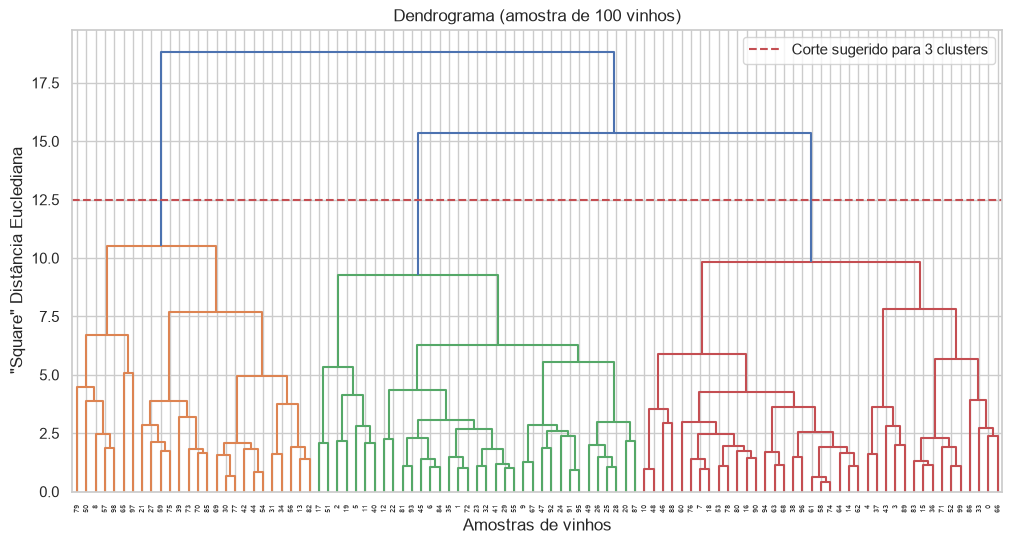

In [12]:
# Produz dendograma com uma amostra dos dados
amostra_indices = np.random.choice(len(X), size=100, replace=False)
X_amostra = X_scaled[amostra_indices]

# Calcular linkage para o dendrograma
Z = linkage(X_amostra, method='ward')

# Plotar dendrograma
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title('Dendrograma (amostra de 100 vinhos)')
plt.xlabel('Amostras de vinhos')
plt.ylabel('"Square" Distância Euclediana')
plt.axhline(y=12.5, color='r', linestyle='--', label='Corte sugerido para 3 clusters')
plt.legend()
plt.show()

In [13]:
# Execucao do modelo HAC
n_clusters_escolhido = 3

linkage_method = 'ward'
hac = AgglomerativeClustering(n_clusters=n_clusters_escolhido, linkage=linkage_method)
clusters = hac.fit_predict(X_scaled)
clusters[:20]

hac = AgglomerativeClustering(n_clusters=n_clusters_escolhido, linkage=linkage_method)
clusters_treino = hac.fit_predict(X_scaled)
clusters_treino[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [14]:
#Adicionando os clusters ao DataFrame principal
df['cluster'] = clusters_treino
df.head()

,citric_acid,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide,cluster
0,-2.164515,-0.699699,0.523880,1.100996,1.779304,0.177941,-0.969152,5,red,1.594818,-1.753919,0
1,-2.164515,-0.544135,1.120736,0.763753,-0.153797,0.979389,-0.631833,5,red,2.565734,-0.786828,0
2,-1.892672,-0.610806,0.957957,0.831202,0.220351,0.779027,-0.631833,5,red,2.061356,-1.345931,0
3,1.641293,-0.699699,0.496751,1.168444,-0.403229,0.311515,-0.631833,6,red,1.865803,-1.191760,0
4,-2.164515,-0.721923,0.496751,1.100996,1.779304,0.177941,-0.969152,5,red,1.426692,-1.599748,0


In [15]:
# Quantos vinhos em cada cluster
df['cluster'].value_counts().sort_index()

cluster
0    1459
1    2572
2    1289
Name: count, dtype: int64

In [16]:
# Resumo dos clusters
clusters_validos = sorted(df['cluster'].unique())
n_clusters_encontrados = len(clusters_validos)
n_pontos_total = len(df)

print('Número de clusters encontrados:', n_clusters_encontrados)
print('Total de pontos:', n_pontos_total)

Número de clusters encontrados: 3
Total de pontos: 5320


In [17]:
# Avaliação rápida com silhouette score

mask_todos = df['cluster'] >= 0
X_todos = X_scaled[mask_todos]
labels_todos = df.loc[mask_todos, 'cluster']

if len(set(labels_todos)) >= 2:
    sil = silhouette_score(X_todos, labels_todos)
    print('Silhouette Score:', round(sil, 4))
else:
    print('Silhouette Score não pode ser calculado: menos de 2 clusters válidos.')

Silhouette Score: 0.231


In [19]:
# Redução dos dados para 2 dimensões usando PCA

from sklearn.decomposition import PCA

# Cria o modelo PCA para reduzir para 2 componentes
pca = PCA(n_components=2)

# Aplica o PCA aos dados padronizados
X_pca = pca.fit_transform(X_scaled)

# Mostra a variância explicada por cada componente
print("Variância explicada pelo PCA 1:", round(pca.explained_variance_ratio_[0], 4))
print("Variância explicada pelo PCA 2:", round(pca.explained_variance_ratio_[1], 4))
print("Variância explicada acumulada:", round(pca.explained_variance_ratio_.sum(), 4))

Variância explicada pelo PCA 1: 0.2766
Variância explicada pelo PCA 2: 0.2495
Variância explicada acumulada: 0.5261


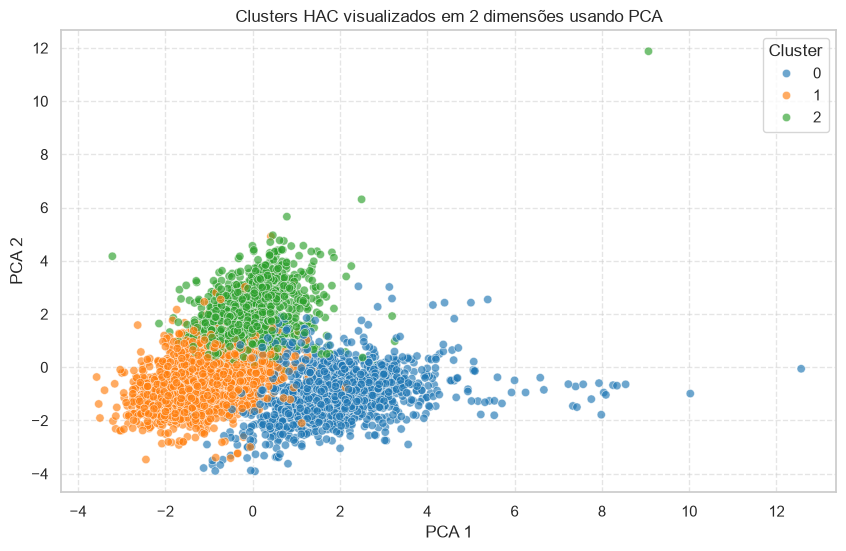

In [20]:
# Visualização dos clusters utilizando PCA

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Gráfico PCA 1 x PCA 2, colorido pelos clusters do HAC

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='cluster',
    palette='tab10',
    alpha=0.65
)

plt.title('Clusters HAC visualizados em 2 dimensões usando PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [22]:
# Obtém os pesos (loadings) das variáveis em PCA1 e PCA2

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=features
)

print(loadings)

                             PCA1      PCA2
citric_acid              0.006371  0.231980
residual_sugar          -0.001333  0.554678
chlorides                0.462940 -0.049538
density                  0.488130  0.354132
pH                       0.071048 -0.286002
sulphates                0.386459 -0.168550
alcohol                 -0.298341 -0.408221
combined_acidity         0.487218 -0.138443
combined_sulfur_dioxide -0.258042  0.463288


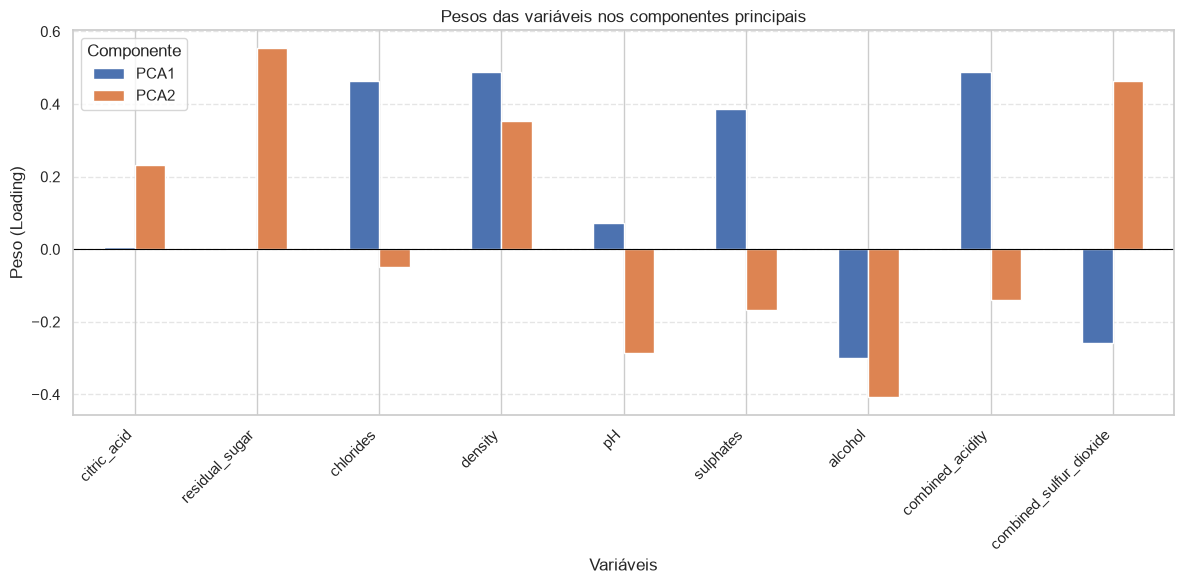

In [23]:
# Gráfico dos pesos das variáveis em PCA1 e PCA2

loadings.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Pesos das variáveis nos componentes principais')
plt.xlabel('Variáveis')
plt.ylabel('Peso (Loading)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Componente')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Calculando Silhouette Scores para todas as variações de linkage...
Linkage 'ward': Melhor Score foi 0.2565 com k = 2
Linkage 'complete': Melhor Score foi 0.8084 com k = 2
Linkage 'average': Melhor Score foi 0.8084 com k = 2
Linkage 'single': Melhor Score foi 0.8084 com k = 2


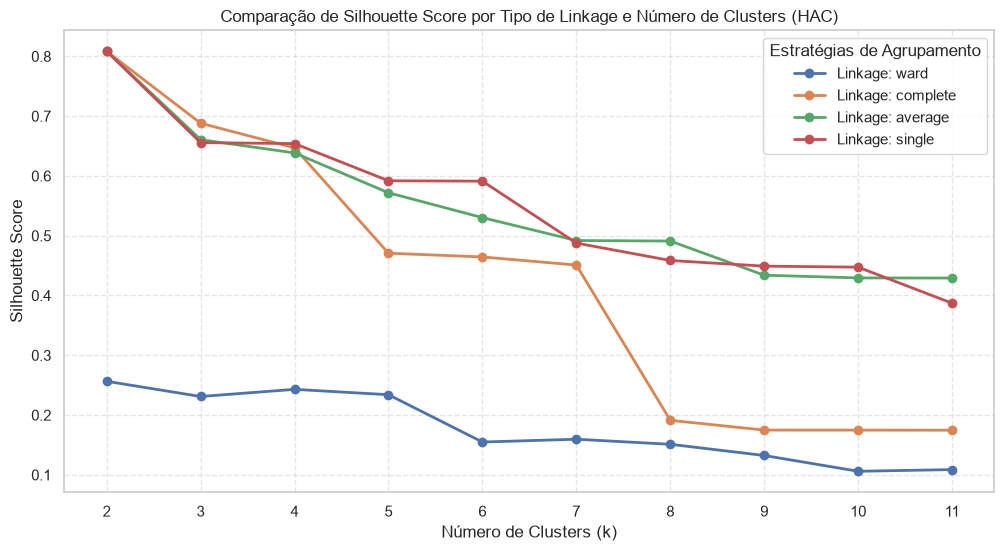

In [ ]:
# Definindo as 4 variações de linkage suportadas pelo HAC
variacoes_linkage = ['ward', 'complete', 'average', 'single']

# Definindo o intervalo para 10 diferentes valores de k (de 2 a 12)
valores_k = range(2, 12)

# Criando a figura do gráfico para plotar todas as linhas juntas
plt.figure(figsize=(12, 6))

print("Calculando Silhouette Scores para todas as variações de linkage...")

# Loop principal: passa por cada tipo de linkage
for metodo_linkage in variacoes_linkage:
    scores_do_metodo = []
    
    # Loop secundário: passa por cada número de clusters (k)
    for k in valores_k:
        # Configura e treina o modelo HAC com o linkage e k atuais
        hac_teste = AgglomerativeClustering(n_clusters=k, linkage=metodo_linkage)
        labels_teste = hac_teste.fit_predict(X_scaled)
        
        # Calcula o silhouette score para esta combinação
        score = silhouette_score(X_scaled, labels_teste)
        scores_do_metodo.append(score)
        
    # Exibe no terminal o melhor resultado encontrado para este método específico
    maior_score = max(scores_do_metodo)
    k_ideal = valores_k[scores_do_metodo.index(maior_score)]
    print(f"Linkage '{metodo_linkage}': Melhor Score foi {maior_score:.4f} com k = {k_ideal}")
    
    # Plota a linha deste método de linkage no gráfico geral
    plt.plot(valores_k, scores_do_metodo, marker='o', linestyle='-', label=f'Linkage: {metodo_linkage}', linewidth=2)

# Customização e finalização do gráfico comparativo
plt.title('Comparação de Silhouette Score por Tipo de Linkage e Número de Clusters (HAC)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(valores_k)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Estratégias de Agrupamento')
plt.show()